## Definizione dell'architettura SimpleCNN

Si definisce una **rete neurale convoluzionale semplice** (`SimpleCNN`) composta da 3 strati convoluzionali 2D.

**Struttura della rete:**
- `conv1`: dal numero di canali in ingresso (`in_ch`, tipicamente 1 per immagini in scala di grigi) a `n_filters` feature maps.
- `conv2`: da `n_filters` a `n_filters` (elaborazione intermedia).
- `conv3`: da `n_filters` ai canali di uscita (`out_ch`, tipicamente 1).

Tutti gli strati usano `padding="same"` (*padded convolution*), che mantiene le dimensioni spaziali (altezza × larghezza) invariate attraverso la rete. Le attivazioni **ReLU** vengono applicate dopo `conv1` e `conv2`, ma **non** dopo `conv3`, poiché l'output è direttamente l'immagine ricostruita.

In [10]:
import torch
from torch import nn

class SimpleCNN(nn.Module):
    def __init__(self, in_ch, out_ch, n_filters, kernel_size=3):
        super().__init__()

        # Define (convolution) layers -> NOTE: padding="same" means "padded convolution"
        self.conv1 = nn.Conv2d(in_channels=in_ch, out_channels=n_filters, kernel_size=kernel_size, padding="same")
        self.conv2 = nn.Conv2d(in_channels=n_filters, out_channels=n_filters, kernel_size=kernel_size, padding="same")
        self.conv3 = nn.Conv2d(in_channels=n_filters, out_channels=out_ch, kernel_size=kernel_size, padding="same")

        self.relu = nn.ReLU()

    def forward(self, x):
        h = self.relu(self.conv1(x))
        h = self.relu(self.conv2(h))
        out = self.conv3(h)
        return out

## Setup dell'ambiente: percorsi, dispositivo, dataset e operatore di degradazione

Questo blocco prepara tutto il necessario per l'addestramento:

1. **Ricerca automatica della cartella radice del corso:** si risale l'albero delle directory partendo dalla directory corrente fino a trovare la cartella `Mayo` (contenente il dataset). Questo rende il notebook portabile indipendentemente da dove viene eseguito.
2. **Import dinamico di IPPy:** si carica il modulo `operators.py` dalla libreria locale `IPPy` usando `importlib.util`, evitando problemi di installazione del pacchetto.
3. **Creazione della cartella `weights`:** se non esiste, viene creata automaticamente per salvare i pesi del modello.
4. **Rilevamento automatico del dispositivo:** la funzione `get_device()` seleziona automaticamente `cuda` (NVIDIA GPU), `mps` (Apple Silicon) o `cpu`, senza hardcodare il valore.
5. **Funzione di rumore gaussiano:** `gaussian_noise(y, noise_level)` genera rumore gaussiano calibrato sulla norma del segnale, assicurando un rapporto segnale/rumore controllato.
6. **Classe `MayoDataset`:** carica le immagini CT, le converte in scala di grigi e le ridimensiona a 256×256.
7. **DataLoader per training e test:** con `batch_size=8`.
8. **Operatore di sfocatura (`Blurring`):** simula un *motion blur* con kernel 9×9 e angolo 20°.

In [11]:
import glob
import importlib.util
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

here = Path.cwd().resolve()
for base in (here, *here.parents):
    if (base / 'Mayo').exists():
        book_root = base
        break
else:
    raise FileNotFoundError('Could not locate the course root containing Mayo.')

for base in (here, *here.parents):
    if (base / 'IPPy').exists():
        ippy_root = base / 'IPPy'
        break
else:
    raise FileNotFoundError('Could not locate the local IPPy package.')

operators_spec = importlib.util.spec_from_file_location('course_ippy_operators', ippy_root / 'operators.py')
operators = importlib.util.module_from_spec(operators_spec)
operators_spec.loader.exec_module(operators)

weights_dir = book_root / 'weights'
weights_dir.mkdir(exist_ok=True)

def get_device():
    if torch.cuda.is_available():
        return 'cuda'
    try:
        if torch.backends.mps.is_available():
            return 'mps'
    except AttributeError:
        pass
    return 'cpu'

def gaussian_noise(y, noise_level):
    e = torch.randn_like(y, device=y.device)
    return e / torch.norm(e) * torch.norm(y) * noise_level

class MayoDataset(Dataset):
    def __init__(self, data_path, data_shape):
        super().__init__()
        self.data_path = data_path
        self.data_shape = data_shape
        self.fname_list = glob.glob(f'{data_path}/*/*.png')

    def __len__(self):
        return len(self.fname_list)

    def __getitem__(self, idx):
        img_path = self.fname_list[idx]
        x = Image.open(img_path).convert('L')
        x = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize(self.data_shape),
        ])(x)
        return x

device = get_device()
train_dataset = MayoDataset(data_path=str(book_root / 'Mayo' / 'train'), data_shape=256)
test_dataset = MayoDataset(data_path=str(book_root / 'Mayo' / 'test'), data_shape=256)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

K = operators.Blurring(
    img_shape=(256, 256),
    kernel_type='motion',
    kernel_size=9,
    motion_angle=20,
)

print('Device:', device)
print('Training images:', len(train_dataset))
print('Test images:', len(test_dataset))
print('Weights directory:', weights_dir)

Device: mps
Training images: 3306
Test images: 327
Weights directory: /Users/mattia.dispigno/University/UniBo/computational imaging/LezioniPy/weights


## Addestramento completo della SimpleCNN

Questo blocco esegue il ciclo di addestramento della rete e include salvataggio, ricaricamento e verifica visiva del modello.

**Configurazione:**
- **Seed:** `torch.manual_seed(0)` per la riproducibilità dei risultati.
- **Ottimizzatore:** `Adam` con learning rate `1e-3`.
- **Loss:** `MSELoss` (errore quadratico medio).
- **Epoche:** 30 (significativamente più di Lecture2 per ottenere risultati migliori).
- **Livello di rumore:** 0.01 (1%).

**Ciclo di training (per ogni epoca):**
1. Per ogni batch `x` dal loader:
   - Si simula la misura degradata: `y = K(x) + rumore`.
   - Si calcola la predizione della rete: `prediction = modello(y)`.
   - Si calcola la loss `MSE(prediction, x)` e si aggiornano i pesi.
2. Si salva la loss media dell'epoca nella storia (*history*).

**Dopo il training:**
- I pesi vengono **salvati su disco** (`weights/CNN.pth`).
- Il modello viene **ricaricato** da file per verificare che il salvataggio sia corretto.
- Si esegue un **test visivo** su un'immagine dal test set, mostrando: ground truth, misura degradata, ricostruzione e curva di training loss.

**Nota:** viene usata `tqdm` per mostrare una barra di progresso durante il training.

/Users/mattia.dispigno/University/UniBo/computational imaging/LezioniPy/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Epoch 1/30: 100%|██████████| 414/414 [00:32<00:00, 12.75it/s, avg_loss=0.002411, batch_loss=0.001003]


Epoch 1: training loss = 0.002411


Epoch 2/30: 100%|██████████| 414/414 [00:30<00:00, 13.68it/s, avg_loss=0.000878, batch_loss=0.000548]


Epoch 2: training loss = 0.000878


Epoch 3/30: 100%|██████████| 414/414 [00:29<00:00, 13.86it/s, avg_loss=0.000697, batch_loss=0.000671]


...

Epoch 28: training loss = 0.000343


Epoch 29/30: 100%|██████████| 414/414 [00:28<00:00, 14.32it/s, avg_loss=0.000342, batch_loss=0.000368]


Epoch 29: training loss = 0.000342


Epoch 30/30: 100%|██████████| 414/414 [00:28<00:00, 14.36it/s, avg_loss=0.000339, batch_loss=0.000268]


Epoch 30: training loss = 0.000339
Saved SimpleCNN weights to: /Users/mattia.dispigno/University/UniBo/computational imaging/LezioniPy/weights/CNN.pth


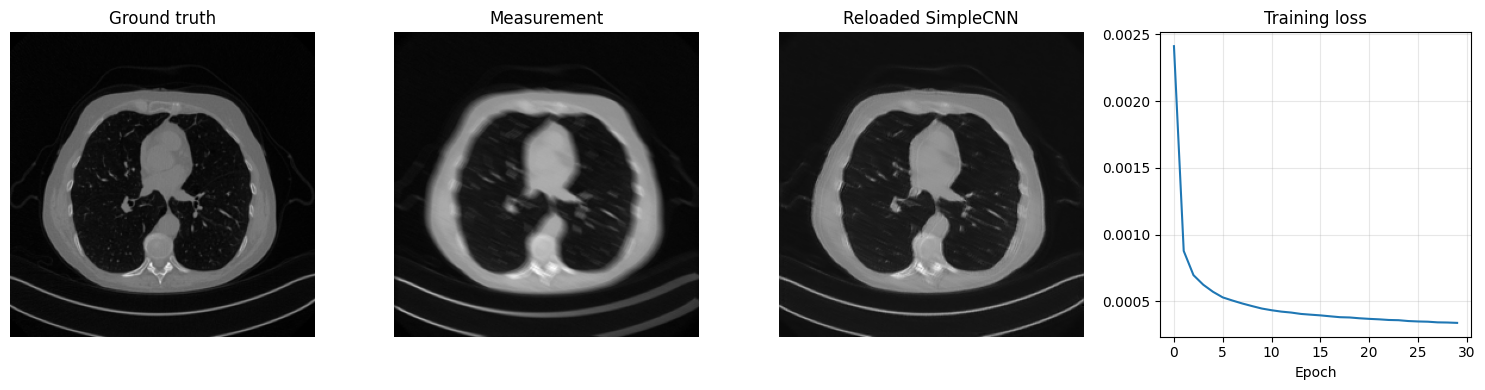

In [12]:
from tqdm.auto import tqdm

torch.manual_seed(0)

model = SimpleCNN(in_ch=1, out_ch=1, n_filters=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

num_epochs = 30
noise_level = 0.01
history = []
weights_path = weights_dir / 'CNN.pth'

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}', leave=True)
    for step, x_batch in enumerate(progress_bar, start=1):
        x_batch = x_batch.to(device)

        with torch.no_grad():
            y_batch = K(x_batch)
            y_batch = y_batch + gaussian_noise(y_batch, noise_level=noise_level)

        prediction = model(y_batch)
        loss = loss_fn(prediction, x_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(batch_loss=f'{loss.item():.6f}', avg_loss=f'{epoch_loss / step:.6f}')

    history.append(epoch_loss / len(train_loader))
    print(f'Epoch {epoch + 1}: training loss = {history[-1]:.6f}')

torch.save(model.state_dict(), weights_path)
print(f'Saved SimpleCNN weights to: {weights_path}')

reloaded_model = SimpleCNN(in_ch=1, out_ch=1, n_filters=32)
reloaded_model.load_state_dict(torch.load(weights_path, map_location='cpu', weights_only=True))
reloaded_model = reloaded_model.to(device)
reloaded_model.eval()

with torch.no_grad():
    x_test = next(iter(test_loader))[0:1].to(device)
    y_test = K(x_test)
    y_test = y_test + gaussian_noise(y_test, noise_level=noise_level)
    x_pred = reloaded_model(y_test)

plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1)
plt.imshow(x_test.cpu().squeeze(), cmap='gray')
plt.title('Ground truth')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(y_test.cpu().squeeze(), cmap='gray')
plt.title('Measurement')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(x_pred.cpu().squeeze(), cmap='gray')
plt.title('Reloaded SimpleCNN')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.plot(history)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Verifica del modello ricaricato da disco

In questo blocco si verifica che il modello salvato su disco funzioni correttamente:
1. Si caricano i pesi da `weights/CNN.pth` in una nuova istanza di `SimpleCNN`.
2. Si prende la prima immagine dal test set.
3. Si genera la misura degradata (blur + rumore) e si applica la rete.
4. Si visualizzano le tre immagini affiancate: ground truth, misura e ricostruzione.

Questo passaggio serve per confermare che i pesi sono stati salvati e ricaricati correttamente.

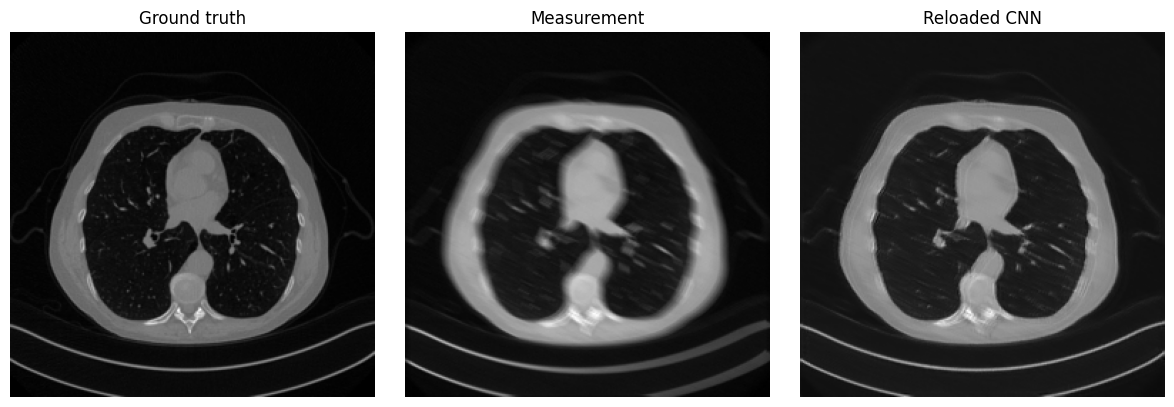

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

# Reload the saved CNN weights and test them on one image.
model = SimpleCNN(in_ch=1, out_ch=1, n_filters=32, kernel_size=3)
model.load_state_dict(torch.load(weights_dir / 'CNN.pth', weights_only=True, map_location='cpu'))
model = model.to(device)
model.eval()

x_true = test_dataset[0].unsqueeze(0).to(device)
with torch.no_grad():
    y_delta = K(x_true)
    y_delta = y_delta + gaussian_noise(y_delta, noise_level=0.01)
    x_rec = model(y_delta)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(x_true.cpu().squeeze(), cmap='gray')
plt.title('Ground truth')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(y_delta.cpu().squeeze(), cmap='gray')
plt.title('Measurement')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(x_rec.cpu().squeeze(), cmap='gray')
plt.title('Reloaded CNN')
plt.axis('off')

plt.tight_layout()
plt.show()

## Visualizzazione delle attivazioni interne della rete (feature maps)

Questo blocco usa i **forward hooks** di PyTorch per intercettare e visualizzare le feature maps prodotte dal primo strato convoluzionale (`conv1`) della rete.

**Come funziona:**
1. Si definisce un dizionario `activation` e una funzione `get_activation(name)` che restituisce un *hook*: una callback che, ogni volta che lo strato viene eseguito, salva il suo output nel dizionario.
2. Si registra l'hook su `model.conv1`.
3. Si esegue un forward pass sull'immagine degradata.
4. Si estraggono le 16 feature maps (su 32 totali) prodotte da `conv1` e si visualizzano in una griglia 4×4.

Questa tecnica è utile per **interpretare** cosa la rete ha imparato: ogni feature map evidenzia diversi pattern (bordi, texture, strutture) nell'immagine.

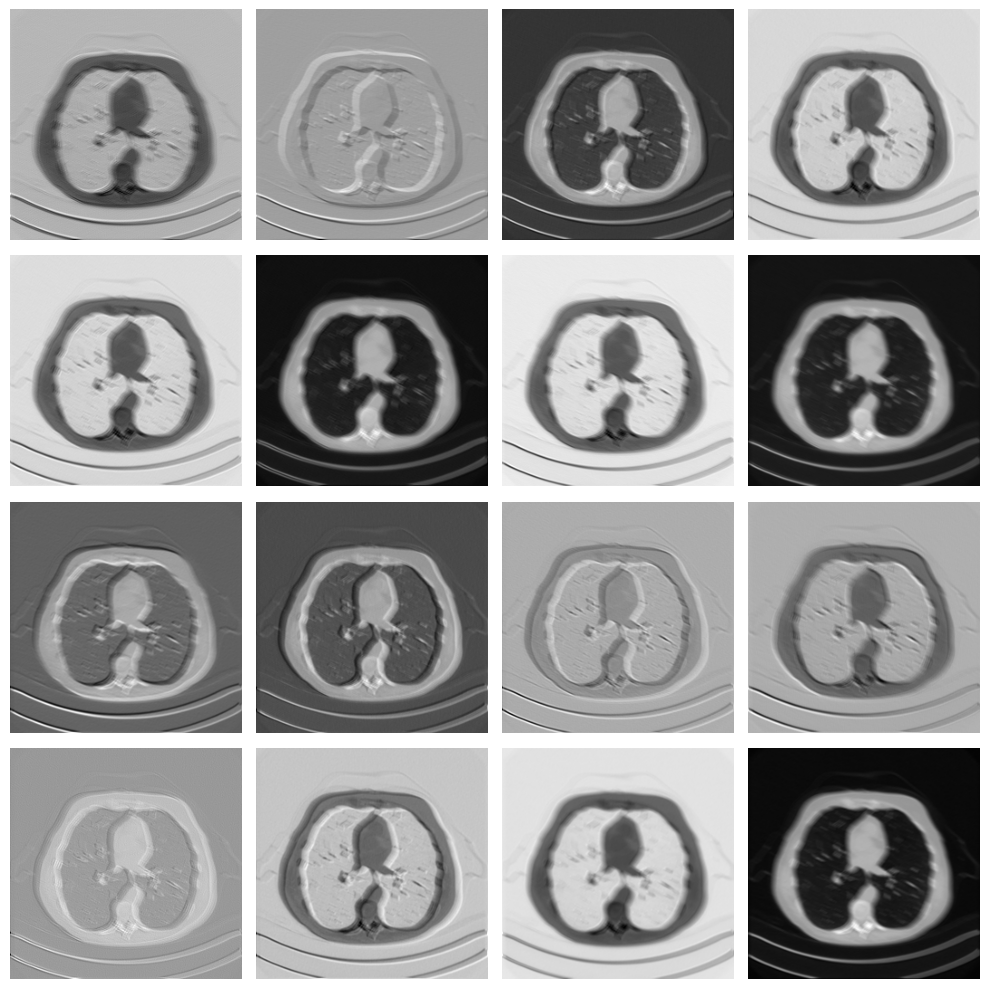

In [14]:
# Variable to store the output
activation = {}

def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

# Register the hook
model.conv1.register_forward_hook(get_activation('conv1'))

# Process image
x_rec = model(y_delta.to(device))

# Get the conv1 activation
conv1_output = activation['conv1']  # Shape: [1, 64, 256, 256]

# Plot all channels
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(conv1_output[0, i].cpu(), cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Conteggio dei parametri addestrabili

Si calcola e stampa il **numero totale di parametri addestrabili** della rete.

Questo è utile per valutare la complessità del modello. `SimpleCNN` con 32 filtri e kernel 3×3 ha un numero relativamente basso di parametri, il che la rende adatta per dimostrazioni didattiche ma limitata per applicazioni reali più complesse.

In [15]:
# Get number of parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_params}")

Total trainable parameters: 9857
